In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline # Using a pipeline for correctness
from imblearn.over_sampling import SMOTE

# Import classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

In [2]:
df = pd.read_csv('/content/environment.csv')
df.head()

,NO2,NOx,NH3,CO,SO2,AQI,AQI_Bucket,AQI_Bucket_Code,NO_ratio,Gas_Total,Pollutant_Mean
0,18.22,17.15,15.85,0.92,27.64,118.0,Moderate,0,1.003857,79.78,15.956
1,15.69,16.46,15.85,0.97,24.55,118.0,Moderate,0,0.898625,73.52,14.704
2,19.30,29.70,15.85,17.40,29.07,118.0,Moderate,0,0.628664,111.32,22.264
3,18.48,17.97,15.85,1.70,18.59,118.0,Moderate,0,0.974170,72.59,14.518
4,21.42,37.76,15.85,22.10,39.33,118.0,Moderate,0,0.552632,136.46,27.292


In [3]:
df.shape

(27171, 11)

In [5]:
df.isnull().sum()

,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0
AQI,0
AQI_Bucket,0
AQI_Bucket_Code,0
NO_ratio,0
Gas_Total,0


In [7]:
features = [
    'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'NO_ratio', 'Gas_Total', 'Pollutant_Mean'
    ]

target = 'AQI_Bucket_Code'

# --- 3. Prepare Data for Modeling ---
X = df[features]
y = df[target]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"New class distribution:\n{y.value_counts()}")

New class distribution:
AQI_Bucket_Code
0    18098
1     5398
2     3675
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

Original features: 8, After polynomial expansion: 36
Epoch 1/100
680/680 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6978 - loss: 0.7501 - val_accuracy: 0.7409 - val_loss: 0.6434 - learning_rate: 0.0010
Epoch 2/100
680/680 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7468 - loss: 0.6457 - val_accuracy: 0.7500 - val_loss: 0.6292 - learning_rate: 0.0010
Epoch 3/100
680/680 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7505 - loss: 0.6408 - val_accuracy: 0.7501 - val_loss: 0.6250 - learning_rate: 0.0010
Epoch 4/100
680/680 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7532 - loss: 0.6286 - val_accuracy: 0.7557 - val_loss: 0.6211 - learning_rate: 0.0010
Epoch 5/100
680/680 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7555 - loss: 0.6251 - val_accuracy: 0.7534 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 6/100
680/680 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7586 - loss: 0.6175 - val_accuracy: 0.7547 - val_loss: 0.6064 - learning_rate: 0.0010
Epoch 7/100
680/680 ━━━━━━━━━

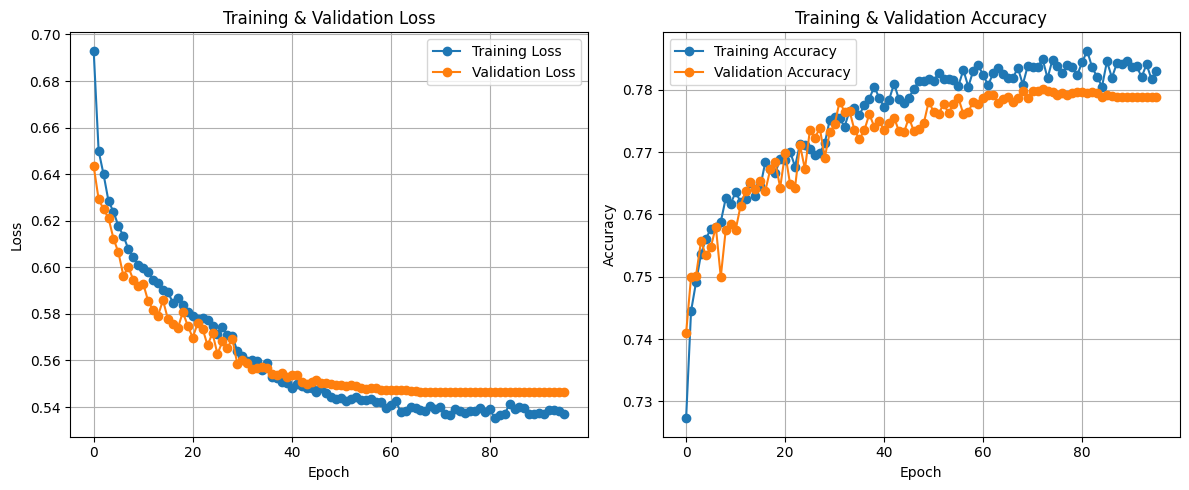

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

# =====================================
# Step 1: Generate polynomial features
# =====================================
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Original features: {X.shape[1]}, After polynomial expansion: {X_poly.shape[1]}")

# =====================================
# Step 2: Split and scale data
# =====================================
X_train, X_test, y_train, y_test = train_test_split(X_poly, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_features = X_train.shape[1]
n_classes = len(np.unique(y_encoded))

# =====================================
# Step 3: Define improved neural network
# =====================================
model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation="relu"),   # Slightly larger for expanded features
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# =====================================
# Step 4: Train model
# =====================================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

# =====================================
# Step 5: Evaluate model
# =====================================
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n✅ Final Test Accuracy with Polynomial Features: {test_acc:.4f}")



import matplotlib.pyplot as plt

# =====================================
# Step 6: Plot training history
# =====================================

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Convert to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional: apply quantization to shrink size
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save the .tflite model
with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model saved as model.tflite")


Saved artifact at '/tmp/tmp0jmtmski'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 36), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138903881031440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138903881032016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138903881032976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138903881032208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138903881033360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138903881033168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138903881033744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138903881033552: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ TFLite model saved as model.tflite
